## Algebraic Loop Concepts

References:
- https://de.mathworks.com/help/simulink/ug/algebraic-loops.html

### Definition

- An algebraic loop occurs when a signal loop in a models contains only blocks that have direct feedthrough.
- Direct feedthrough refers to components that use the input value for the current time step to calculate the output value of the current time step.
- If a signal loop contains only components with direct feedthrough, circular dependencies of output and input values in the same time step arise.
- The resulting equation is an algebraic equation, that requires a solution at each time step and adds computational costs.
- **Examples:** Math functions, Gains, Adders, Subtractors, etc.
- **Non-examples:** Integrators, Delays, etc. (these do not have direct feedthrough)

### Simple Algebraic Loop Example

- ODEs are systems of equations of the form:
$$\dot{x}(t) = f(x(t), t)$$

where:
- $x(t)$ is the state vector
- $t$ is the independent time variable

Some systems of equations include additional constraints, that involve the independent variable and the state variables, but not the derivative of the state vector.
These systems are called differential-algebraic equations (DAEs). The term algebraic refers to the fact that these equations do not involve derivatives.
DAES can be expressed in the semi-explicit form:
$$\begin{align}
\dot{x}(t) &= f(x(t), x_a(t), t) \\
0 &= g(x(t), x_a(t), t)
\end{align}$$

where:
- $f$ and $g$ can be vector-valued functions
- The first equation represents the differential part of the system
- The second equation represents the algebraic part of the system
- $x(t)$ are the state variables
- $x_a(t)$ are the algebraic variables

Models with algebraic loops define a system of differential-algebraic equations. These equations are solved numerically for $x_a$ at each step of a simulation that uses an ODE solver.

**Equations**

The system consists of a source, an inner and outer subtractor, and an integrator connected in a loop. The equations governing the system are as follows:

$$\begin{align*}

u(t) &= 1 \\

\dot{x}(t) &= x_a \\

0 &= u(t) - x(t) - 2x_a(t) \\

\end{align*}$$

From the algebraic equation, we obtain:

$$x_a(t) = \frac{u(t) - x(t)}{2}$$

Substituting this into $\dot{x}(t) = x_a(t)$:

$$\dot{x}(t) + \frac{1}{2}x(t) = \frac{1}{2}u(t)$$

This is a first-order linear ordinary differential equation (ODE) for $x(t)$.

For the given input $u(t) = 1$, and the initial condition $x(0) = 0$, we can solve this ODE analytically:

1. The integrating factor is $e^{\frac{1}{2}t}$.

2. Multiplying both sides of the ODE by the integrating factor:

$$\frac{d}{dt}\left(e^{\frac{1}{2}t} x(t)\right) = \frac{1}{2}e^{\frac{1}{2}t}$$

3. Integrating both sides with respect to $t$:
$$e^{\frac{1}{2}t} x(t) = e^{\frac{1}{2}t} + C$$

4. Solving for $x(t)$:
$$x(t) = 1 + Ce^{-\frac{1}{2}t}$$


where $C$ is a constant determined by the initial condition.

Applying the initial condition $x(0) = 0$:

$$0 = 1 + C \implies C = -1$$
Thus, the analytical solution for $x(t)$ is:
$$x(t) = 1 - e^{-\frac{1}{2}t}$$

In [1]:
import sys
import numpy as np
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

from docs.plot_setup import set_professional_style
plt = set_professional_style(latex=False)

from integrator import Integrator
from subtractor import Subtractor
from source import Source
from squarer import Squarer

from SysSimX.system.connection import Connection
from SysSimX.system.system import System
from SysSimX.viz.sysgraph import SystemGraphVisualizer

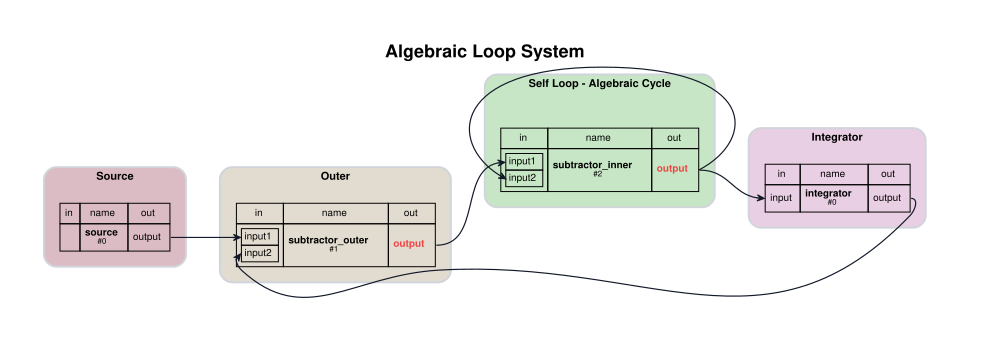

In [2]:
# Instantiate components
source = Source(name='source')
source.group = "Source"

subtractor_outer = Subtractor(name='subtractor_outer')
subtractor_outer.group = "Outer"

subtractor_inner = Subtractor(name='subtractor_inner')
subtractor_inner.group = "Self Loop - Algebraic Cycle"

integrator = Integrator(name='integrator')
integrator.group = "Integrator"

components = [source, subtractor_outer, subtractor_inner, integrator]

# Define connections
c1 = Connection(src_comp=source.name, src_port=source.output_specs['output'].name,
                dst_comp=subtractor_outer.name, dst_port=subtractor_outer.input_specs['input1'].name)

c2 = Connection(src_comp=subtractor_outer.name, src_port=subtractor_outer.output_specs['output'].name,
                dst_comp=subtractor_inner.name, dst_port=subtractor_inner.input_specs['input1'].name)

# Algebraic loop connections
c3 = Connection(src_comp=subtractor_inner.name, src_port=subtractor_inner.output_specs['output'].name,
                dst_comp=integrator.name, dst_port=integrator.input_specs['input'].name)

c4 = Connection(src_comp=subtractor_inner.name, src_port=subtractor_inner.output_specs['output'].name,
                 dst_comp=subtractor_inner.name, dst_port=subtractor_inner.input_specs['input2'].name)
                
# Feedback from integrator output to subtractor_outer
c5 = Connection(src_comp=integrator.name, src_port=integrator.output_specs['output'].name,
                dst_comp=subtractor_outer.name, dst_port=subtractor_outer.input_specs['input2'].name)

connections = [c1, c2, c3, c4, c5]

# Create system and add components and connections
system = System(name="Algebraic Loop System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.compute_execution_order()

visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

**Reference Solution**

In [3]:
def x(t):
    return 1 - np.exp(-0.5 * t)

t0 = 0
tf = 10
dt = 0.01

t_an_vals = np.linspace(t0, tf, int((tf - t0) / dt) + 1)
x_an_vals = x(t_an_vals)

In [4]:
algorithms = ('Jacobi', 'Gauss-Seidel', 'IJCSA')

results = {algorithm: None for algorithm in algorithms}

for algorithm in algorithms:
    system.history.clear()
    system.algorithm = algorithm
    system.initialize(t0, tf)
    system.run(t0, tf, dt)
    history = system.get_history()
    results[algorithm] = history

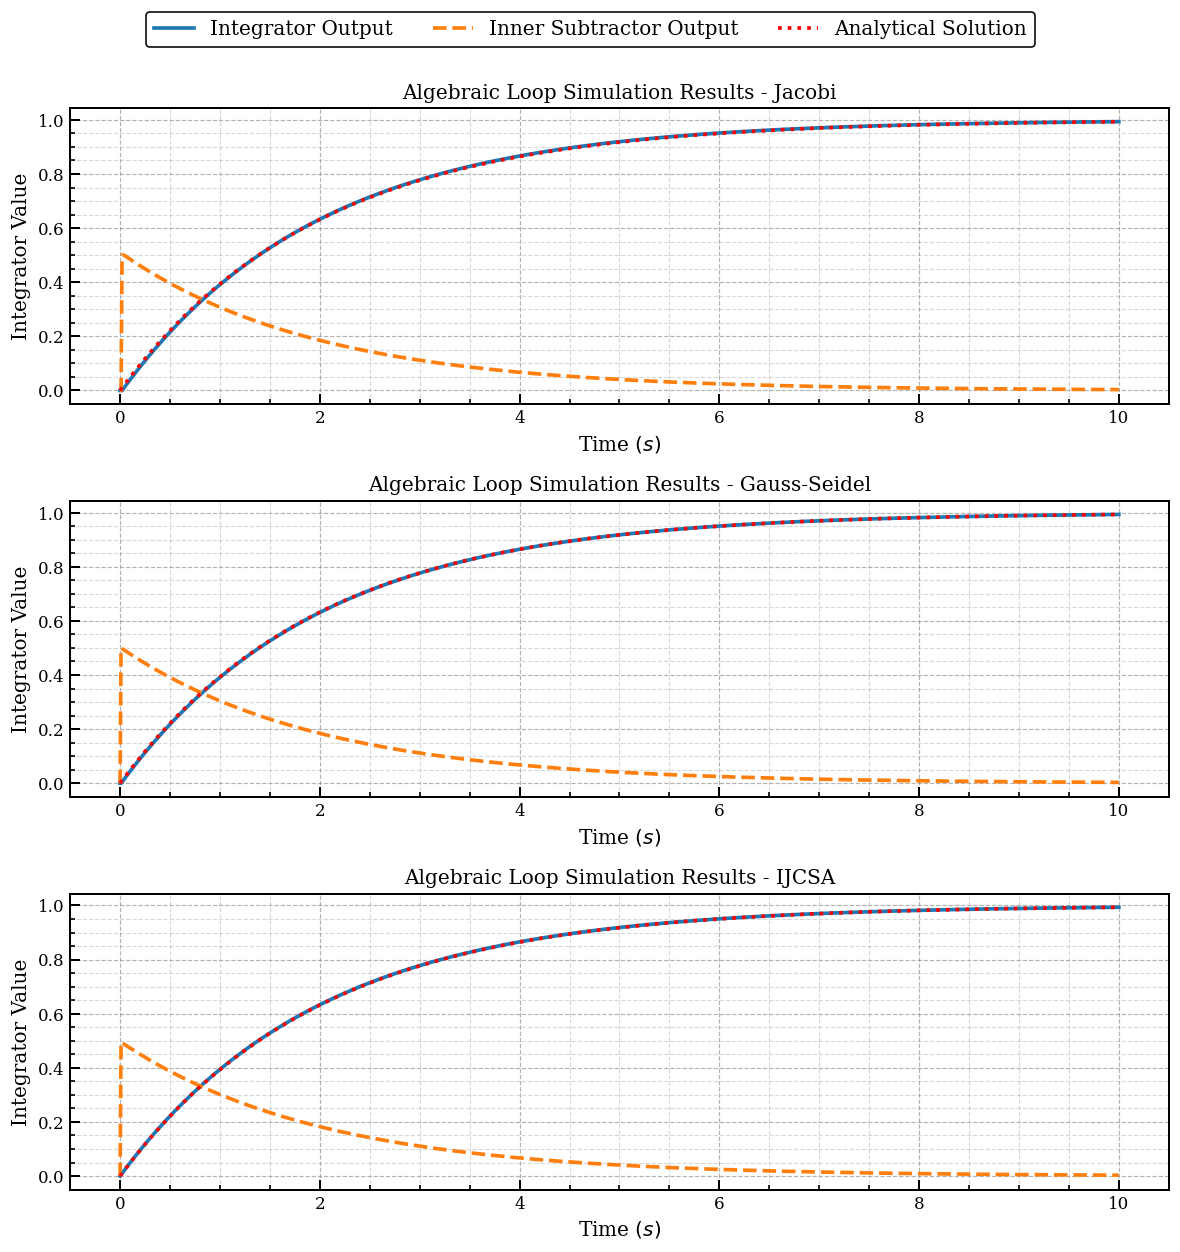

In [5]:
fig, axs = plt.subplots(len(algorithms), 1, figsize=(10, 10))

for i, algo in enumerate(algorithms):
    res = results[algo]
    t_vals, integrator_hist = res['integrator']
    int_out_vals = integrator_hist['output']

    _, sub_inner_hist = res['subtractor_inner']
    sub_inner_out_vals = sub_inner_hist['output']

    axs[i].plot(t_vals, int_out_vals, label='Integrator Output')
    axs[i].plot(t_vals, sub_inner_out_vals, label='Inner Subtractor Output', linestyle='--')
    axs[i].plot(t_an_vals, x_an_vals, label='Analytical Solution', linestyle=':', color='r')
    axs[i].set_title(f'Algebraic Loop Simulation Results - {algo}')
    axs[i].set_xlabel('Time $(s)$')
    axs[i].set_ylabel('Integrator Value')

# One legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major')
    ax.grid(True, which='minor', alpha=0.3)

plt.tight_layout()
plt.show()

----------------------------

In [6]:
def F(y: float) -> float:
    old_out = subtractor_inner.outputs['output'].get()
    old_in = subtractor_inner.inputs['input2'].get()
    subtractor_inner.inputs['input2'].set(y, t=0.0)
    subtractor_inner.do_step(t=0.0, dt=0.0)
    y_out = subtractor_inner.outputs['output'].get()
    # Reset to old values
    subtractor_inner.inputs['input2'].set(old_in, t=0.0)
    subtractor_inner.outputs['output'].set(old_out, t=0.0)
    return y_out

In [7]:
subtractor_inner.set_inputs({'input1': 1.0, 'input2': 0.0}, t=0.0)
subtractor_inner.do_step(t=0.0, dt=0.0)
y = subtractor_inner.get_outputs()['output']

for _ in range(10):
    Fy = F(y)
    g = y - Fy
    if abs(g) < 1e-10:
        break
    # Numerical derivative
    eps = 1e-8 * (1.0 + abs(y))
    Fp = F(y + eps)
    Fm = F(y - eps)
    dF = (Fp - Fm) / (2 * eps)
    dg = 1.0 - dF
    if abs(dg) < 1e-12:
        print("Derivative too small, stopping iteration.")
        y = Fy
    else:
        y = y - g / dg
    
    # Commit the solution to the component
    subtractor_inner.outputs['output'].set(y, t=0.0)
    subtractor_inner.inputs['input2'].set(y, t=0.0)

    print(f"iteration {_}: y = {y}, g = {g}")


iteration 0: y = 0.5000000005623004, g = 1.0
iteration 1: y = 0.5, g = 1.1246008568832622e-09


In [8]:
subtractor_inner.get_outputs()

{'output': 0.5}

In [9]:
subtractor_inner.inputs

{'input1': PortState(spec=PortSpec(name='input1', type=<PortType.REAL: 'real'>, direction='in', unit=None, description=None), value=1.0, t_last=0.0),
 'input2': PortState(spec=PortSpec(name='input2', type=<PortType.REAL: 'real'>, direction='in', unit=None, description=None), value=0.5, t_last=0.0)}